---
<p style="text-align: center;font-size: 2em;font-weight: bold;">
Projet numérique de Probabilités 2025/26
</p>

---


# Introduction

On va s'intéresser à la simulation de champs aléatoires gaussiens. On peut définir un champ aléatoire Gaussien comme une collection de variables aléatoires indexées par un ensemble telles que toute combinaison linéaire finie de ces variables aléatoires suit une loi normale. Pour simplifier, nous nous intéresserons à des champs aléatoires gaussiens définis sur une grille régulière de points dans un domaine  $\mathbb{R}^2$. 

Un champ aléatoire Gaussien est entièrement caractérisé par son espérance et sa fonction de covariance. L'espérance est une fonction qui attribue à chaque point du domaine la valeur moyenne de la variable aléatoire associée à ce point. La fonction de covariance est une fonction qui décrit comment les variables aléatoires associées à deux points différents du domaine sont corrélées entre elles. 

Un exemple classique de fonction de covariance est la fonction exponentielle quadratique (ou gaussienne) définie par :
$$C(x, y) = \sigma^2 \exp\left(-\frac{\|x - y\|^2}{a}\right)$$
où  $\sigma^2$ est la variance,  $a$ est le facteur d'échelle, et $\|x - y\|$ est la distance euclidienne entre les points  $x$ et $y$.
Une telle fonction de covariance implique que les points proches dans le domaine ont des valeurs de champ aléatoire fortement corrélées, tandis que les points éloignés ont des valeurs faiblement corrélées. Elle est souvent utilisée pour modéliser des phénomènes naturels où la corrélation diminue avec la distance. 

Dans ce projet, nous allons implémenter une méthode pour simuler des champs aléatoires gaussiens sur une grille régulière de points dans un domaine  $\mathbb{R}^2$. Nous utiliserons dans un premier temps la méthode de la décomposition de Cholesky pour générer des échantillons de champs aléatoires gaussiens à partir de leur fonction de covariance. Dans un second temps, nous explorerons un méthode plus efficace basée sur la représentation spectrale de la fonction de covariance. Enfin, nous verrons comment conditionner ces simulations sur des observations ponctuelles.

# Simulation par la méthode de Cholesky

Quitte à réarranger les points de la grille, on peut supposer que l'on a une liste finie de points  $x_1, x_2, \ldots, x_n$ dans  $\mathbb{R}^2$ où l'on souhaite simuler le champ aléatoire Gaussien. La fonction de covariance  $C$ permet de construire la matrice de covariance  $K$ définie par :

$$K_{ij} = C(x_i, x_j)$$

On va implementer la méthode de Cholesky pour générer des réalisations de champs aléatoires gaussiens à partir de cette matrice de covariance.

1. Ecrire une fonction "covariance_gaussienne" qui prend en entrée une matrice de distances, ainsi que les paramètres  $\sigma^2$ et  $a$, et qui retourne la valeur de la fonction de covariance gaussienne entre ces deux points.

In [1]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt

np.random.seed(12345)

def covariance_gaussienne(distance, sigma, a):
    return (sigma**2)*np.exp(-distance**2 / a)

2. Discrétiser le domaine  $[0, 1] \times [0, 1]$ en une grille régulière de  $n \times n$ points (par exemple,  $n = 50$). Construire la matrice de distances entre tous les points de la grille.

In [2]:
def grille(n):
    grille_x = np.linspace(0, 1, n)
    grille_y = np.linspace(0, 1, n)
    points = np.array([(x, y) for x in grille_x for y in grille_y])
    return points

def matrice_distance(points):
    return distance_matrix(points, points)

matrice_distance(grille(2))


array([[0.        , 1.        , 1.        , 1.41421356],
       [1.        , 0.        , 1.41421356, 1.        ],
       [1.        , 1.41421356, 0.        , 1.        ],
       [1.41421356, 1.        , 1.        , 0.        ]])

3. Utiliser la fonction "covariance_gaussienne" pour construire la matrice de covariance $K$ en évaluant la fonction de covariance pour chaque paire de points dans la grille puis calculer la décomposition de Cholesky de $K$ (voir *np.linalg.cholesky*).

On choisira ici  $\sigma^2 = 1$ et  $a = 0.05$.

NB : Pour assurer la stabilité numérique, on peut ajouter un petit terme de régularisation à la diagonale de la matrice de covariance avant de calculer la décomposition de Cholesky (par exemple,  $10^{-10} I$ où  $I$ est la matrice identité).

In [3]:
sigma2 = 1.0
a = 0.05
n = 100
D = matrice_distance(grille(n))

def matrice_covariance_gaussienne(D, sigma2, a):
    return sigma2 * np.exp(-D**2 / a)

def decomposition_cholesky_gaussienne(n, sigma2, a):
    L = np.linalg.cholesky(matrice_covariance_gaussienne(D, sigma2, a) + 1e-10 * np.eye(n*n)) 
    return L

K = matrice_covariance_gaussienne(D, sigma2, a)
L = np.linalg.cholesky(K + 1e-10 * np.eye(n*n)) 
#L_bis = decomposition_cholesky_gaussienne(n, sigma2, a) # K=LL^T

#print((L_bis == L))

4. Générer et représenter une réalisation du champ aléatoire Gaussien centré et de covariance $K$.

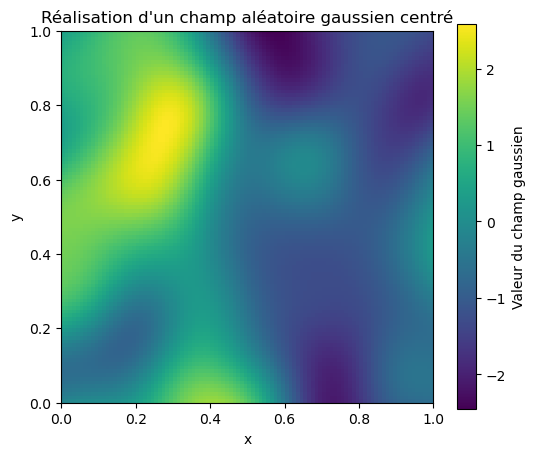

In [4]:
def realisation_champ_gaussien(n, sigma2, a):
    
    z = np.random.randn(n*n)

    x = np.dot(decomposition_cholesky_gaussienne(n, sigma2, a), z)

    x_2D = x.reshape((n, n))
    return x_2D

x_2D = realisation_champ_gaussien(n, sigma2, a)

plt.figure(figsize=(6,5))
plt.imshow(x_2D, extent=[0,1,0,1], origin='lower', cmap='viridis')
plt.colorbar(label='Valeur du champ gaussien')
plt.title("Réalisation d'un champ aléatoire gaussien centré")
plt.xlabel("x")
plt.ylabel("y")
plt.show()




5. Essayer d'augmenter le nombre de pas de discrétisation. Que remarquez-vous ? Expliquer pourquoi.

On voit que lorsque $n$ augmente, le temps d'exécution augmente considérablement ; ceci est dû à la complexité du processus de génération du champ. La décomposition de Cholesky se fait en $O(N^3)$ sur une matrice de taille $N \times N$, or ici on l'applique sur une matrice de taille $n^2 \times n^2$ (due à la matrice des distances). Ce qui fait une complexité totale en $O(n^6)$, ce qui explique l'explosion du temps d'exécution.

# Simulation par la méthode spectrale 

Vu les limitations de la méthode de Cholesky pour des grilles fines, nous allons explorer une méthode alternative basée sur la représentation spectrale de la fonction de covariance. 

1. Soit $C(h) = \exp\left(-\frac{\|h\|^2}{a}\right)$, où $h \in \mathbb{R}^2$. Montrer que :
$$ C(h) = \int_{\mathbb{R}^2} \cos(\langle w, h \rangle) \frac{a}{4\pi}\exp\left(-\frac{a\|w\|^2}{4}\right) dw $$

NB: on pourra s'inspirer du calcul de la fonction caractéristique d’un vecteur gaussien en annexe du chapitre IV du cours.

Soit $ X = (X_1,X_2) $ un vecteur gaussien d'espérance $m = 0 \in \mathbb{R}^2 $ et de matrice de covariance $ C = \frac{2}{a}I_2$.
On sait alors que la fonction caractéristique de ce vecteur gaussien a pour expression (cf. page 28 du cours Proba IV):

\begin{equation}
\psi_X(h) = \exp\left(-\frac{\|h\|^2}{a}\right) = C(h)
\end{equation}

Or, la fonction caractéristique de $X$ est définie comme :

\begin{equation}
\psi_X(h) = \int_{\mathbb{R}^2}\exp\left(i\langle h, X \rangle\right) \mathbb{P}_X(dx) = \int_{\mathbb{R}^2}\exp\left(i\langle h, w \rangle\right) f_X(w) dw
\tag{2}
\end{equation}

Par ailleurs, on a vu au chapitre 2 que la densité du vecteur X s'écrit pour $ w \in \mathbb{R}^2$ :

$$f_X(w) = \frac{1}{2\pi\sqrt{\det (C)}}\exp \left(-\frac{1}{2}(w-m)^t C^{-1}(w-m)\right)$$

Or $ m = 0 $, $ C^{-1} = \frac{2}{a}I_2 $ et $\det(C)=\left(\frac{2}{a} \right)^2$, d'où :
\begin{equation}
f_X(w) = \frac{a}{4\pi}\exp \left(-\frac{a\|w\|^2}{4}\right)
\tag{3}
\end{equation}

On obtient donc en reinjectant $(3)$ dans $(2)$ :

$$\psi_X(h) = \int_{\mathbb{R}^2}\left(\cos(\langle h, w \rangle) + i \sin(\langle h, w \rangle)\right) \frac{a}{4\pi}\exp \left(-\frac{a\|w\|^2}{4}\right) dw $$

Or d'après $(1)$, $\psi_X(h) \in \mathbb{R}$ et donc il ne reste que le terme en $\cos(\langle h, X \rangle)$. On obtient bien l'expression attendue pour la fonction de covariance :

$$C(h) = \psi_X(h) = \int_{\mathbb{R}^2}\cos(\langle h, w \rangle)\frac{a}{4\pi}\exp \left(-\frac{a\|w\|^2}{4}\right) dw $$


2. Soient $W$ et $\Phi$ deux variables aléatoires indépendantes, de lois respectives $\mathcal{N}(0, \frac{2}{a} I_2)$, avec $I_2$ la matrice identité de dimension 2, et $\mathcal{U}[0, 2\pi[$. Montrer que la variable aléatoire définie en tout point $x \in \mathbb{R}^2$ par :
$$ Z(x) = \sqrt{2} \cos(\langle W, x \rangle + \Phi) $$
est d'espérance nulle et de fonction de covariance $C$.

#### a. Espérance de Z(x)
$\mathbb{E}(Z(x)) = \sqrt{2}\mathbb{E}\left(\cos(\langle W, x \rangle + \Phi)\right ) $

D'après la formule de l'espérance totale, on a:

\begin{equation}
\mathbb{E}\left(\mathbb{E}(\cos(\langle W, x \rangle + \Phi) |W)\right) = \mathbb{E}(\cos(\langle W, x \rangle + \Phi))
\end{equation}

Soit $w \in \mathbb{R}^2$, on a :

$$\mathbb{E}(\cos(\langle W, x \rangle + \Phi) |W=w) = \mathbb{E}(\cos(\langle w, x \rangle + \Phi) |W=w)$$

Or $\Phi$ et $W$ sont indépendantes (donc la loi conditionnelle de $\Phi$ sachant $W$ est la même que sa loi marginale), d'où :
\begin{equation}
\mathbb{E}(\cos(\langle W, x \rangle + \Phi) |W=w) = \mathbb{E}(\cos(\langle w, x \rangle + \Phi))
\tag{2}
\end{equation}

De plus, puisque $\Phi$ suit une loi $\mathcal{U}[0, 2\pi[$, on a:

$$\mathbb{E}(\cos(\langle w, x \rangle + \Phi)) = \frac{1}{2\pi}\int_0^{2\pi} \cos(\langle w, x \rangle + y)dy = \frac{1}{2\pi} \left[ \sin(\langle w, x \rangle + y) \right]_0^{2\pi}=0
$$

On réinjecte ce résultat dans $(2)$ :

$$ \mathbb{E}(\cos(\langle W, x \rangle + \Phi) |W) = 0 $$

L'espérance d'une variable aléatoire certaine étant égale à l'unique valeur prise par celle-ci, on a :

$$\mathbb{E}\left(\mathbb{E}(\cos(\langle W, x \rangle + \Phi) |W)\right) = 0$$

On conclut finalement avec $(1)$ :

$$\mathbb{E}(Z(x)) = 0$$

#### b. Fonction de covariance

On note $C_Z$ la fonction de covariance de $Z$. On a par définition :

$$C_Z(x,y)=\textrm{Cov}(Z(x),Z(y))=\mathbb{E}(Z(x)Z(y))- \mathbb{E}(Z(x))\mathbb{E}(Z(y))$$

Par ce qui précède, on a $\mathbb{E}(Z(x))=\mathbb{E}(Z(y))=0$, ce qui donne donc :

$$C_Z(x,y)=\mathbb{E}(Z(x)Z(y)) = 2\mathbb{E}(\cos(\langle W, x \rangle + \Phi)\cos(\langle W, y \rangle + \Phi)) $$

Comme précédemment, on utilise l'indépendance de $\Phi$ et de $W$ en conditionnant sur $W$.
Soit $w \in \mathbb{R}^2$, on a :

$$2\mathbb{E}(\cos(\langle W, x \rangle + \Phi)\cos(\langle W, y \rangle + \Phi)|W=w) = 2\mathbb{E}(\cos(\langle w, x \rangle + \Phi)\cos(\langle w, y \rangle + \Phi)) $$

On linéarise ce produit de cosinus :

$$\cos(\langle w, x \rangle + \Phi)\cos(\langle w, y \rangle + \Phi) = \frac{1}{2}\left(\cos(\langle w, x \rangle + \langle w, y \rangle + 2\Phi) + \cos(\langle w, x \rangle - \langle w, y \rangle )\right)$$

D'où : 

$$2\mathbb{E}(\cos(\langle W, x \rangle + \Phi)\cos(\langle W, y \rangle + \Phi)|W=w) = \mathbb{E}\left(\cos(\langle w, x+y \rangle + 2\Phi)\right) +\mathbb{E}\left( \cos(\langle w, x-y \rangle)\right)$$

Le premier terme est nul, en effet :

$$\mathbb{E}(\cos(\langle w, x+y \rangle + 2\Phi)) = \frac{1}{2\pi}\int_0^{2\pi} \cos(\langle w, x+y \rangle + 2v)dv = \frac{1}{2\pi} \left[ \frac{1}{2}\sin(\langle w, x+y \rangle + 2v) \right]_0^{2\pi}=0
$$

On obtient donc :

$$\mathbb{E}(Z(x)Z(y)|W) = 2\mathbb{E}(\cos(\langle W, x \rangle + \Phi)\cos(\langle W, y \rangle + \Phi)|W) =\mathbb{E}\left( \cos(\langle W, x-y \rangle)\right)=\mathbb{E}(\cos(J))$$

 - Déterminons la loi suivie par la variable aléatoire $J=\langle W, x-y \rangle = \langle W, h \rangle $ (on pose $h = x-y$) :

$$J = h_1W_1 + h_2W_2$$

Or $W$ est un vecteur gaussien donc toute combinaison linéaire de ses composantes suit une loi normale uni-dimensionnelle. De plus :

$ \mathbb{E}(J) = h_1\mathbb{E}(W_1) + h_2\mathbb{E}(W_2) = 0$ pusique $ W = (W_1,W_2) $ est un vecteur gaussien d'espérance $m = 0 \in \mathbb{R}^2 $

Et comme $W$ suit une loi $\mathcal{N}(0, \frac{2}{a} I_2)$, $W_1$ et $W_2$ sont indépendantes et de variance $\frac{2}{a}$, on a donc :

$\mathbb{V}(J) = h_1^2\mathbb{V}(W_1) + h_1^2\mathbb{V}(W_2) = \frac{2}{a}(h_1^2+h_2^2) = \frac{2}{a}\|h\|^2$

On conclut que J suit une loi suit une loi $\mathcal{N}(0, \frac{2}{a}\|h\|^2)$.

On va maintenant utiliser la fonction caractéristique d'une variable gaussienne pour calculer $\mathbb{E}(\cos(J))$ en remarquant que $\mathcal{Re}(\mathbb{E}(\exp(iJ))) = \mathbb{E}(\cos(J))$

Or on sait que pour une variable gaussienne centrée $G ∼ \mathcal{N}(0, \sigma^2)$, on a :

$$\psi_G(u) = \mathbb{E}(e^{iuG}) = e^{-\frac{\sigma^2u^2}{2}}$$

En particulier pour $u = 1$, on a : $\mathbb{E}(e^{iG}) = e^{-\frac{\sigma^2}{2}} \in \mathbb{R}$

D'où finalement en appliquant ce résultat à $J∼\mathcal{N}(0, \frac{2}{a}\|h\|^2)$ :
$$\mathbb{E}(\cos(J)) = \mathcal{Re}(\mathbb{E}(e^{iJ})) =\mathbb{E}(e^{iG}) = e^{-\frac{\sigma^2}{2}} = e^{-\frac{\|h\|^2}{a}} $$

On obtient ainsi :

$$\mathbb{E}(Z(x)Z(y)|W) = 2\mathbb{E}(\cos(\langle W, x \rangle + \Phi)\cos(\langle W, y \rangle + \Phi)|W) = \mathbb{E}(\cos(J)) = e^{-\frac{\|h\|^2}{a}} $$

Finalement, par la formule de l'espérance totale, on obtient le résultat attentdu :

$$ C_Z(x,y)=\mathbb{E}(Z(x)Z(y)) = \mathbb{E}(\mathbb{E}(Z(x)Z(y)|W)) = e^{-\frac{\|x-y\|^2}{a}} = C(x,y) $$




3. Soient les suites de variables aléatoires indépendantes $(W_n)_{n \in \mathbb{N}}$ et $(\Phi_n)_{n \in \mathbb{N}}$ telles que $W_n \sim \mathcal{N}(0, \frac{2}{a} I_2)$ et $\Phi_n \sim \mathcal{U}([0, 2\pi])$. Montrer que pour tout ensemble fini de points  $x_1, \ldots, x_n$ dans  $\mathbb{R}^2$ , le vecteur aléatoire $Y = (Y(x_1), \ldots, Y(x_n))$ où :
$$ Y(x_i) = \sqrt{\frac{2}{N}} \sum_{k=1}^{N} \cos(\langle W_k, x_i \rangle + \Phi_k) $$
tend vers un vecteur aléatoire de loi normale multivariée d'espérance nulle et de matrice de covariance $K$ définie par  $K_{ij} = C(x_i - x_j)$.

#### Idée : utiliser le théorème central limite multidimmensionnel
On va appliquer le théorème central limite multidimmensionnel (cf p.21 du cours Proba IV) aux vecteurs $X_k=(\sqrt{2} \cos(\langle W_k, x_1 \rangle + \Phi_k),...,\sqrt{2} \cos(\langle W_k, x_n \rangle + \Phi_k))$

On a alors : $$ \frac{1}{\sqrt{N}} \sum_{k=1}^{N} X_k = \frac{S_N}{\sqrt{N}} = Y$$

De plus, d'après la question 2., on a bien que les $X_k$ sont indépendants et de même loi, d'espérance $m = 0 \in \mathbb{R}^n$ et avec pour matrice de covariance $K$ définie par  $K_{ij} = C(x_i - x_j)$.

Les hypothèses nécessaires pour appliquer le théorème central limite multidimmensionnel sont donc bien remplies, on a ainsi que le vecteur aléatoire Y converge en loi vers un vecteur aléatoire gaussien d'espérance nulle et de matrice de covariance K. 

4. Implémenter une fonction basée sur cette méthode pour simuler un champ aléatoire gaussien sur une grille régulière de points dans le domaine  $[0, 1] \times [0, 1]$. Cette fonction prendra en entrée les coordonnées des points de la grille, $a$ et  $N$ et retournera une réalisation du champ aléatoire gaussien simulé.

In [ ]:
def champ_aleatoire_gaussien_spectral(n, a, N):
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)

    sigma = np.sqrt(2 / a)
    w = sigma * np.random.randn(N, 2)
    phi = np.random.uniform(0, 2*np.pi, N)

    wx = w[:, 0].reshape(N, 1, 1)
    wy = w[:, 1].reshape(N, 1, 1)
    phi = phi.reshape(N, 1, 1)

    x_b = x.reshape(1, 1, n)
    y_b = y.reshape(1, n, 1)

    argument = (wx * x_b) + (wy * y_b) + phi
    
    somme = np.sum(np.cos(argument), axis=0)

    return np.sqrt(2) * somme / np.sqrt(N)

def champ_aleatoire_gaussien_spectral_coord(coord, a, N): # fonction pour la question 4 de la 3ème partie "Simulation conditionnelle"
    

    sigma = np.sqrt(2 / a)
    w = sigma * np.random.randn(N, 2)
    phi = np.random.uniform(0, 2*np.pi, N)

    wx = w[:, 0].reshape(N, 1)
    wy = w[:, 1].reshape(N, 1)
    phi = phi.reshape(N, 1)

    x_b = coord[:, 0].reshape(1, -1)
    y_b = coord[:, 1].reshape(1, -1)

    argument = (wx * x_b) + (wy * y_b) + phi
    
    somme = np.sum(np.cos(argument), axis=0)

    return np.sqrt(2) * somme / np.sqrt(N)

5. Tester cette fonction pour différentes valeurs du nombre de points de discrétisation et de $N$. Proposer un diagnostic permettant de calibrer $N$ afin que les résultats soient conformes aux attentes. Comparer les résultats obtenus avec ceux de la méthode de Cholesky. Quels sont les avantages et les inconvénients de chaque méthode ?

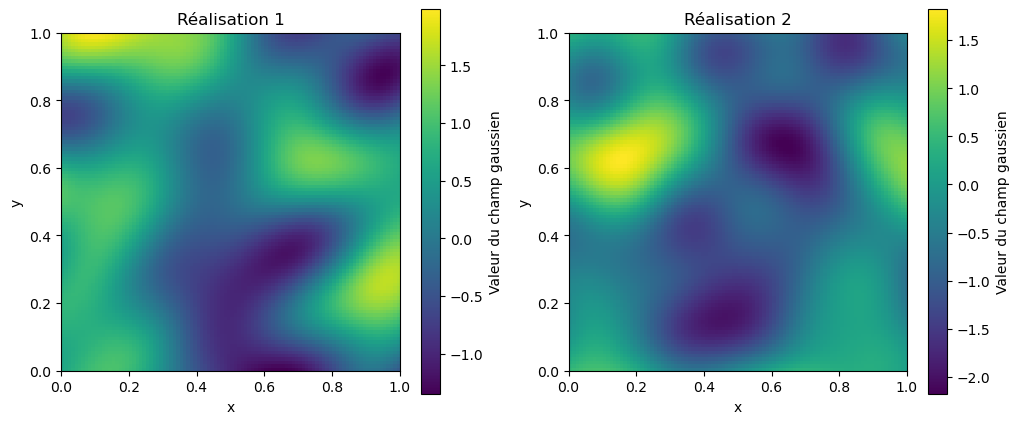

In [7]:

a = 0.05
n = 100
N = 200

n2 = 100
N2 = 20000

test1 = champ_aleatoire_gaussien_spectral(n, a, N)
test2 = champ_aleatoire_gaussien_spectral(n2, a, N2)

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1)
plt.imshow(test1, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(label='Valeur du champ gaussien')
plt.title("Réalisation 1")
plt.xlabel("x")
plt.ylabel("y")


plt.subplot(1, 2, 2)
plt.imshow(test2, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(label='Valeur du champ gaussien')
plt.title("Réalisation 2")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

#### Calcul de la complexité temporelle de la fonction champ_aleatoire_gaussien_spectral et comparaison avec la méthode de Cholesky

Chacune des étapes : calcul de "argument", du cosinus et la somme sur l'axe 0 sont en $\mathcal{O}(Nn^2)$ (une grille de $n^2$ points et pour lesquels une somme de $N$ termes est réalisée). On a donc une bien meilleure complexité temporelle pour la méthode spectrale (en $\mathcal{O}(Nn^2)$) en comparaison avec la méthode de Cholesky (en $\mathcal{O}(n^6)$). De plus la dépendance par rapport à la taille de la grille n'est plus que quadratique, ainsi la méthode spectrale est bien plus adaptée à des grilles de grande taille (par rapport à la méthode de Cholesky). Néanmoins la précision de la méthode spectrale dépend en plus du choix de $N$.

# Simulation conditionnelle 

On suppose désormais que l'on dispose de valeurs observées du champ aléatoire Gaussien en certains points du domaine. On souhaite simuler des réalisations conditionnelles du champ aléatoire Gaussien en tenant compte de ces observations. On travaillera désormais avec une grille de taille $100 \times 100$.
Soit $X$ un vecteur aléatoire Gaussien partitionné en deux sous-vecteurs $X_1$ et $X_2$, où $X_1$ représente les points observés et $X_2$ les points non observés. 

1. Rappeler l'expression de la distribution jointe de $X = (X_1, X_2)$ puis de la distribution conditionnelle de $X_2$ sachant $X_1$. Montrer que la différence entre l'espérance conditionnelle et le vecteur des points non observés est un vecteur Gaussien d'espérance nulle indépendant du vecteur des points observés.

On rappelle la fonction densité de $X=(X_1,X_2)$ (avec $K$ la matrice de covariance de $X$ et $n = n_1 + n_2$ la taille du vecteur aléatoire gaussien centré $X$) :
$$ f_X(x) = \frac{1}{(2\pi)^{n/2}\sqrt{\det (K)}}\exp (-\frac{1}{2}(x^tK^{-1}x)) $$
$$K = \begin{pmatrix}
K_{11} & K_{12} \\
K_{21} & K_{22}
\end{pmatrix},\textrm{ avec } K_{11} \textrm{ et } K_{22}\textrm{ respectivement les matrices de covariance de } X_1 \textrm{ et } X_2  $$

Par ailleurs, on a d'après le cours Proba III : 

$$f_{X_2|X_1=x_1}(x_2) = \frac{1}{(2\pi)^{n_2/2}\sqrt{\det (KS_{X_2})}}\exp \left(-\frac{1}{2}(x_2-\psi(x_1))^tKS_{X_2}^{-1}(x_2-\psi(x_1))\right)$$

avec $\psi(x_1) = K_{12}K_{11}^{-1}x_1$

Par identification, on en déduit que $\mathbb{E}[X_2|X_1] = K_{12}K_{11}^{-1}X_1$

On s'intéresse désormais à la différence $\epsilon$ entre l'espérance conditionnelle et le vecteur des points non observés :

$$\epsilon = \mathbb{E}[X_2|X_1] - X_2 = K_{12}K_{11}^{-1}X_1 - X_2 = K = \begin{pmatrix}
K_{12}K_{11}^{-1} & I \\
\end{pmatrix}
\begin{pmatrix}
X_1 \\
X_2
\end{pmatrix}$$

Ainsi $\epsilon$ est une transformation linéaire d'un vecteur aléatoire gaussien, on en déduit que $\epsilon$ est gaussien.

Puis on montre que $\mathbb{E}(\epsilon) = 0$ en utilisant la linéartité de l'espérance puis la formule de l'espérance totale :

$$\mathbb{E}(\epsilon) = \mathbb{E}(\mathbb{E}[X_2|X_1] - X_2) = \mathbb{E}(\mathbb{E}[X_2|X_1]) - \mathbb{E}(X_2) = 0$$

Enfin montrons que $\epsilon$ et $X_1$ sont indépendantes. Pour cela on va montrer que $\textrm{Cov}(\epsilon,X_1) = 0$ car dans le cas de vecteurs gaussiens cela équivaut à l'indépendance, en effet :
##### Démonstration : $\mathrm{Cov}(Y_1,Y_2)=0\quad \Longleftrightarrow \quad Y_1 \perp Y_2$ pour $Y_1,Y_2$ gaussiens

 
$$
\textrm{Soit }Y=
\begin{pmatrix}
Y_1 \\ Y_2
\end{pmatrix}
\sim \mathcal{N}\big(m, \Sigma\big), \quad \Sigma =
\begin{pmatrix}
\Sigma_{11} & \Sigma_{12} \\
\Sigma_{21} & \Sigma_{22}
\end{pmatrix}$$


On suppose que $\mathrm{Cov}(Y_1, Y_2) = \Sigma_{12} = 0 $

La densité gaussienne s'écrit :
$$f_{Y_1,Y_2}(y_1,y_2)
=
\frac{1}{(2\pi)^{n/2} \det(\Sigma)^{1/2}}
\exp\Biggl(
-\frac12
\begin{pmatrix}y_1-m_1 \\ y_2-m_2\end{pmatrix}^\top
\Sigma^{-1}
\begin{pmatrix}y_1-m_1 \\ y_2-m_2\end{pmatrix}
\Biggr).
$$

Comme $\Sigma$ est diagonale par blocs,

$$\Sigma =
\begin{pmatrix}
\Sigma_{11} & 0 \\
0 & \Sigma_{22}
\end{pmatrix},
$$
on a :
$$
\Sigma^{-1} =
\begin{pmatrix}
\Sigma_{11}^{-1} & 0 \\
0 & \Sigma_{22}^{-1}
\end{pmatrix},
\quad
\det(\Sigma) = \det(\Sigma_{11})\,\det(\Sigma_{22}).
$$

De plus, le terme quadratique se sépare :
$$
(y_1-m_1)^\top \Sigma_{11}^{-1} (y_1-m_1) +
(y_2-m_2)^\top \Sigma_{22}^{-1} (y_2-m_2).
$$

Grâce aux deux points précédents, la densité jointe se factorise :
$$
f_{Y_1,Y_2}(y_1,y_2) = f_{Y_1}(y_1)\, f_{Y_2}(y_2).
$$

Or cette factorisation de la densité implique que $Y_1$ et $Y_2$ sont indépendants.

On revient à notre objectif initial, à savoir montrer que $\textrm{Cov}(\epsilon,X_1) = 0$. Par bilinéarité de la covariance, on a: 

$$ \textrm{Cov}(\epsilon,X_1) = \textrm{Cov}(\mathbb{E}[X_2|X_1],X_1) - \textrm{Cov}(X_2,X_1) = \textrm{Cov}(K_{12}K_{11}^{-1}X_1,X_1) - \textrm{Cov}(X_2,X_1) = K_{12}K_{11}^{-1}\textrm{Cov}(X_1) - K_{12} $$
$$ \textrm{Cov}(\epsilon,X_1) = K_{12}K_{11}^{-1}K_{11} - K_{12} = 0 $$

Finalement, on peut conclure que $\epsilon$ et $X_1$ sont indépendantes.


On va donc chercher à simuler directement cette différence pour obtenir des réalisations conditionnelles du champ aléatoire Gaussien.

2. Générer 50 points uniformément répartis dans le domaine  $[0, 1] \times [0, 1]$ et simuler des observations du champ aléatoire Gaussien en ces points.


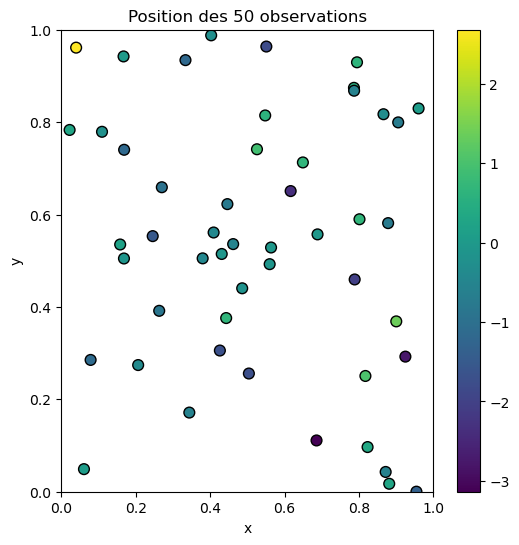

In [15]:

sigma2 = 1.0
a = 0.05
grid_size = 100
nb_obs = 50

obs_coords = np.random.uniform(0, 1, size=(nb_obs, 2))
distances = distance_matrix(obs_coords, obs_coords)


K11 = matrice_covariance_gaussienne(distances, sigma2, a)


L1 = np.linalg.cholesky(K11 + 1e-10 * np.eye(nb_obs))
u_vec = np.random.normal(size=nb_obs)
obs_values = np.dot(L1, u_vec)

plt.figure(figsize=(6, 6))
plt.scatter(obs_coords[:, 0], obs_coords[:, 1], c=obs_values, cmap="viridis", s=60, edgecolors='black')

plt.colorbar() 
plt.title(f"Position des {nb_obs} observations")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()



3. Calculer l'espérance conditionnelle aux points de la grille et la représenter.

NB : Pour assurer la stabilité numérique, on doit ajouter un terme de régularisation plus important à la diagonale de la matrice de covariance avant de calculer son inverse ($10^{-2} I$ conviendra ici).

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


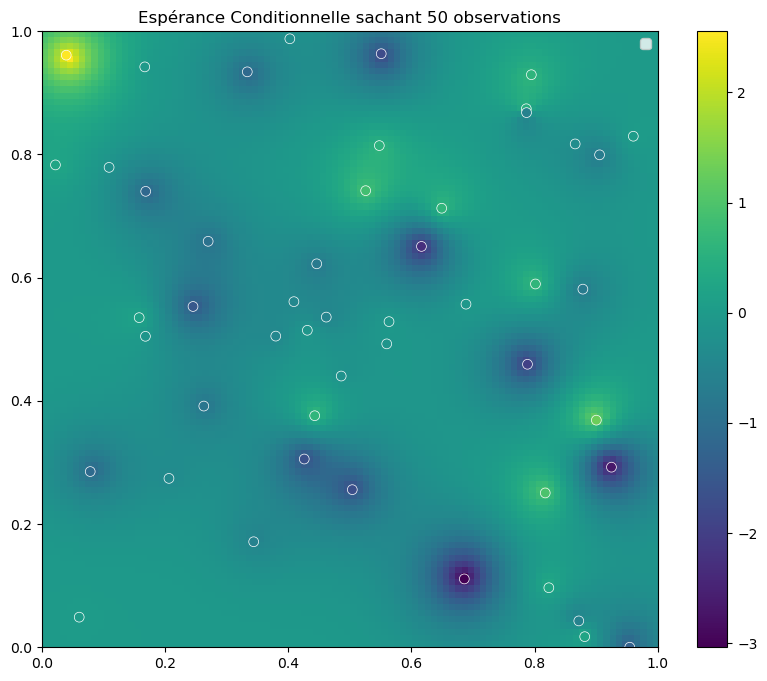

: 

In [ ]:
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)

grill = np.vstack(np.array([[[i,j]for i in x] for j in y]))

K21 = matrice_covariance_gaussienne(distance_matrix(grill, obs_coords), sigma2, a)

K11_inv = np.linalg.inv(K11 + 1e-2*np.eye(nb_obs))

esp_cond_ligne = K21 @ (K11_inv @ obs_values)

esp_cond = esp_cond_ligne.reshape((grid_size, grid_size))

plt.figure(figsize=(10, 8))
im = plt.imshow(esp_cond, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(im)

plt.scatter(obs_coords[:, 0], obs_coords[:, 1], c=obs_values, cmap='viridis', 
            edgecolors='white', s=50, linewidth=0.5)

plt.title(f'Espérance Conditionnelle sachant {nb_obs} observations')
plt.legend()
plt.show()

4. Pour générer de manière indépendante la différence entre l'espérance conditionnelle et le vecteur des points non observés, on génère une seconde réalisation du champ aléatoire aux points de la grille **et** aux coordonnées des points observés par la méthode spectrale. On calcule ensuite la différence entre cette réalisation et l'espérance conditionnelle sachant les valeurs simulées aux coordonnées des points observés. Enfin, on additionne cette différence à l'espérance conditionnelle sachant les observations pour obtenir une réalisation conditionnelle du champ aléatoire Gaussien sur la grille. Implémenter cette approche et représenter une réalisation conditionnelle du champ aléatoire Gaussien sur la grille.

In [ ]:
all_pt = np.vstack((obs_coords, grill))
all_simu = champ_aleatoire_gaussien_spectral_coord(all_pt, a, 200)

obs_simu = all_simu[:nb_obs].flatten()  
grid_simu = all_simu[nb_obs:].flatten() 

obs_simu_col = obs_simu.reshape(-1, 1)

esp_cond_spectral_col = K21 @ (K11_inv @ obs_simu_col)

esp_cond_spectral_ligne = esp_cond_spectral_col.flatten()

simu_cond_ligne = esp_cond_ligne + (grid_simu - esp_cond_spectral_ligne)

simu_cond = simu_cond_ligne.reshape((grid_size, grid_size))


plt.figure(figsize=(10, 8))
plt.imshow(simu_cond, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(label='Simulation Conditionnelle')

plt.scatter(obs_coords[:, 0], obs_coords[:, 1], c=obs_values, cmap='viridis', 
            edgecolors='white', s=60, label='Vraies Observations')

plt.title('Simulation Conditionnelle (Rugueuse mais respecte les points)')
plt.legend()
plt.show()

5. Générer 500 simulations conditionnelles et comparer la moyenne empirique de ces simulations avec l'espérance conditionnelle calculée précédemment. Que constate-t-on ? Expliquer pourquoi.

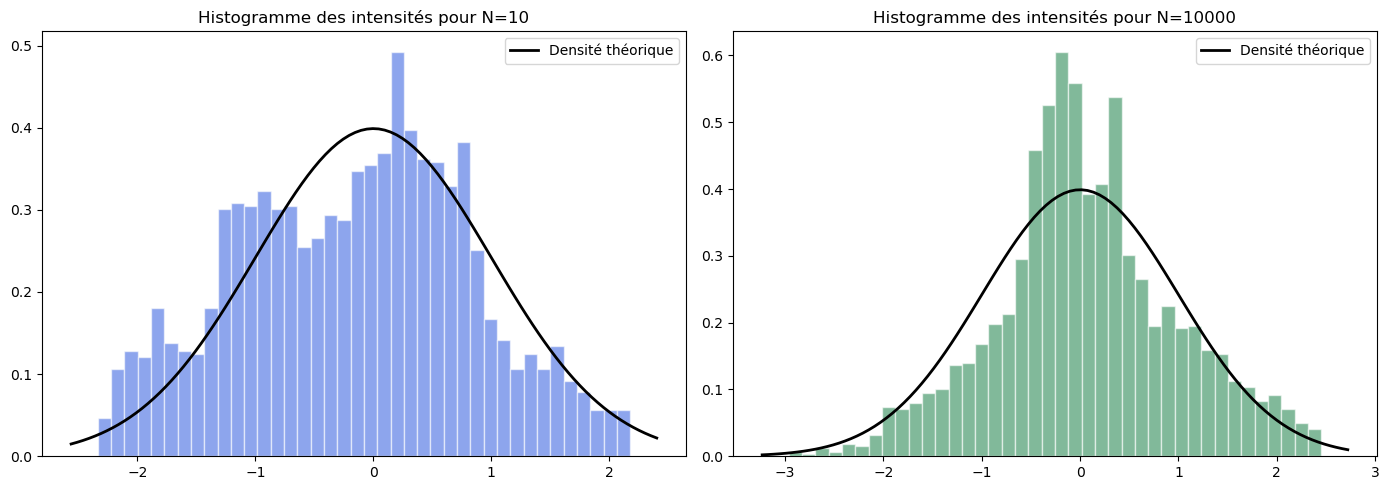

Test de Kolmogorov-Smirnov (N=10)    : p-value = 1.23e-03
Test de Kolmogorov-Smirnov (N=10000) : p-value = 6.40e-05


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

a = 0.05
n_points = 50

# Simulation pour deux valeurs de N
Z_10 = champ_aleatoire_gaussien_spectral(n_points, a, 10).flatten()
Z_10000 = champ_aleatoire_gaussien_spectral(n_points, a, 10000).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Affichage pour N = 10
axes[0].hist(Z_10, bins=40, density=True, alpha=0.6, color='royalblue', edgecolor='white')
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
# On trace la cloche gaussienne théorique N(0, 1)
axes[0].plot(x, stats.norm.pdf(x, 0, 1), 'k', linewidth=2, label='Densité théorique')
axes[0].set_title("Histogramme des intensités pour N=10")
axes[0].legend()

# Affichage pour N = 10000
axes[1].hist(Z_10000, bins=40, density=True, alpha=0.6, color='seagreen', edgecolor='white')
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[1].plot(x, stats.norm.pdf(x, 0, 1), 'k', linewidth=2, label='Densité théorique')
axes[1].set_title("Histogramme des intensités pour N=10000")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tests quantitatifs de Kolmogorov-Smirnov
# On standardise empiriquement pour tester la normalité intrinsèque
Z_10_std = (Z_10 - np.mean(Z_10)) / np.std(Z_10)
Z_10000_std = (Z_10000 - np.mean(Z_10000)) / np.std(Z_10000)

ks_10 = stats.kstest(Z_10_std, 'norm')
ks_10000 = stats.kstest(Z_10000_std, 'norm')

print(f"Test de Kolmogorov-Smirnov (N=10)    : p-value = {ks_10.pvalue:.2e}")
print(f"Test de Kolmogorov-Smirnov (N=10000) : p-value = {ks_10000.pvalue:.2e}")

**Diagnostic pour calibrer $N$ : Analyse de la distribution empirique**

La validité de la méthode spectrale s'appuie sur le Théorème Central Limite. Une excellente alternative visuelle et quantitative consiste à superposer l'histogramme des valeurs simulées avec la densité de probabilité théorique de la loi normale, complétée par un test d'adéquation formel.

* *L'approche visuelle (Histogrammes)* : Pour un $N$ trop petit (par exemple $N=10$), l'histogramme des intensités du champ révèle des déformations claires par rapport à la courbe en cloche idéale (asymétrie, pics irréguliers). Lorsque $N$ devient grand, l'histogramme converge et s'aligne parfaitement sous la cloche de la distribution gaussienne théorique.
* *L'approche quantitative (Test de Kolmogorov-Smirnov)* : Le test K-S permet de mesurer formellement la distance entre la fonction de répartition empirique de notre simulation et celle d'une loi normale. Une $\textit{p-value}$ très faible (proche de $0$) signale un $N$ insuffisant, entraînant le rejet de la normalité. En observant la $\textit{p-value}$ croître de manière significative avec $N$, on peut déterminer un seuil numérique objectif pour calibrer l'algorithme sans dépendre d'une appréciation purement visuelle. 
$\footnotesize{Idée}$ $\footnotesize{proposée}$ $\footnotesize{par}$ $\footnotesize{Gemini,}$ $\footnotesize{particulierement}$ $\footnotesize{pertinente.}$

**Comparaison Cholesky vs Spectrale :**

* **Méthode de Cholesky :**
    * *Avantages :* La méthode est exacte. Les réalisations générées suivent parfaitement la loi normale souhaitée, sans erreur d'approximation asymptotique.
    * *Inconvénients :* C'est une méthode extrêmement coûteuse en calcul $\mathcal{O}(n^6)$. Il est impossible en pratique d'utiliser Cholesky pour simuler de grandes images (ex: au-delà d'une grille de $100 \times 100$, la matrice $10000 \times 10000$ devient trop difficile à inverser ou même à stocker).
    
* **Méthode Spectrale :**
    * *Avantages :* Elle est très rapide et nécessite très peu de mémoire. La complexité algorithmique n'est que de $\mathcal{O}(N \times n^2)$. Il est possible de simuler des champs très haute résolution (ex: $500 \times 500$) en à peine quelques secondes.
    * *Inconvénients :* C'est une méthode d'approximation. Si le paramètre $N$ est mal calibré (trop faible), le champ n'aura pas un comportement pleinement gaussien. 

# Simulation non-stationnaire

On souhaite désormais simuler un champ aléatoire Gaussien non-stationnaire, c'est-à-dire dont la fonction de covariance dépend de la position dans le domaine. Ces modèles plus complexes offrent une plus grande flexibilité pour modéliser des phénomènes naturels. En particulier, on va chercher à faire varier la valeur du paramètre d'échelle $a$ en fonction de la position. On considère une fonction de covariance de la forme :
$$C(x, y) = 2\frac{\sqrt{a(x) a(y)}}{a(x)+a(y)} \exp\left(-\frac{2\|x - y\|^2}{a(x)+a(y)}\right),$$
où $a : [0,1]^2 \to \mathbb{R}_+^*$ est une fonction définissant le paramètre d'échelle en chaque point du domaine.

Pour générer des réalisations de ce champ aléatoire non-stationnaire, on peut adapter la méthode spectrale en utilisant une approche locale. Précisément, on va considérer la modification suivante de la méthode spectrale :

$$Z(x) = \sqrt{\frac{2f_x(W)}{g(W)}}\cos(\langle W, x \rangle + \Phi)$$

où $W$ et $\Phi$ sont deux variables aléatoires indépendantes, de lois respectives $\mathcal{N}(0, \frac{2}{a} I_2)$ et $\mathcal{U}[0, 2\pi[$, et où $f_x$ est la densité de la loi $\mathcal{N}(0, \frac{2}{a(x)} I_2)$ et $g$ est la densité de la loi $\mathcal{N}(0, \frac{2}{a} I_2)$ pour $a = \inf_{x \in [0,1]^2} a(x)>0$, avec $a>0$.

1. Justifier que cette modification permet de simuler un champ aléatoire Gaussien non-stationnaire avec la fonction de covariance donnée précédemment. Quelle technique de simulation vue en cours est-elle utilisée ici ?

2. Implémenter cette méthode pour simuler un champ aléatoire Gaussien non-stationnaire sur une grille régulière de points dans le domaine  $[0, 1] \times [0, 1]$. On choisira, par exemple, une fonction $a(x)$ variant linéairement selon l'axe des ordonnées entre deux valeurs $a_{min}=0.01$ et $a_{max}=0.1$ sur le domaine. Commenter les résultats obtenus.

#### 1.

Montrons que $\textrm{Cov}(Z(x),Z(y)) = C(x,y) $

En suivant le même cheminement qu'à la question 2. de la partie sur la méthode spectrale (au facteur $\sqrt{\frac{f_x(W)}{g(W)}}$ près), on abouti à :

$$\mathbb{E}(Z(x)) = 0, \quad \mathbb{E}(Z(x)Z(y)|W) = \mathbb{E}\left(\frac{\sqrt{f_x(W)f_y(W)}}{g(W)} \cos(\langle W, x-y \rangle)\right)$$

On pose $h(W) = \frac{\sqrt{f_x(W)f_y(W)}}{g(W)} \cos(\langle W, x-y \rangle)$

Comme $g$ est la densité de $W$, on a :

$$\mathbb{E}(h(W)) = \int_{\mathbb{R}^2} h(w)g(w)dw = \int_{\mathbb{R}^2}\sqrt{f_x(w)f_y(w)} \cos(\langle w, x-y \rangle)dw$$

Remarque : $\mathbb{E}(h(W)) = \mathbb{E} (\mathbb{E}(Z(x)Z(y)|W)) = \mathbb{E}(Z(x)Z(y))$ par la formule de l'espérance totale. Et comme à la question 2. de la partie sur la méthode spectrale, on a $ \textrm{Cov}(Z(x),Z(y))= \mathbb{E}(Z(x)Z(y))$

Par ailleurs, d'après la question 1. de la $2^{ème}$ partie, on a:

$$f_x(w) = \frac{a(x)}{4\pi}\exp \left(-\frac{a(x)\|w\|^2}{4}\right), \quad f_y(w) = \frac{a(y)}{4\pi}\exp \left(-\frac{a(y)\|w\|^2}{4}\right) $$

D'où :

$$ \sqrt{f_x(w)f_y(w)} = \frac{\sqrt{a(x)a(y)}}{4\pi} \exp \left(-\frac{a(x)+a(y)}{8}\|w\|^2 \right)$$

On en déduit :

$$\mathbb{E}(h(W)) = \frac{\sqrt{a(x)a(y)}}{4\pi} \int_{\mathbb{R}^2}\exp \left(-\frac{a(x)+a(y)}{8}\|w\|^2 \right)\cos(\langle w, x-y \rangle)dw$$

On reconnait la transformé de Fournier d'une Gaussienne :

$$\mathbb{E}(h(W)) = \frac{\sqrt{a(x)a(y)}}{4\pi} \times \frac{8\pi}{a(x)+a(y)} \exp \left(-\frac{\|x-y\|^2}{4}\times \frac{8}{a(x)+a(y)} \right)$$

Pour rappel $\mathbb{E}(h(W)) = \textrm{Cov}(Z(x),Z(y))$, on obtient ainsi l'esxpression souhaitée :

$$\textrm{Cov}(Z(x),Z(y)) = \frac{2\sqrt{a(x)a(y)}}{a(x)+a(y)} \exp \left(-\frac{2\|x-y\|^2}{a(x)+a(y)} \right) = C(x,y)$$

La technique de simulation que l'on va utiliser est l'échantillonage d'importance (le terme en $\sqrt{\frac{f_x(W)}{g(W)}}$ pouvant être interprété en poids d'importance nous met sur cette piste). Il s'agit bien d'une méthode de simulation d'un vecteur gaussien à densité (avec la fonction de covariance $C$).

#### 2.

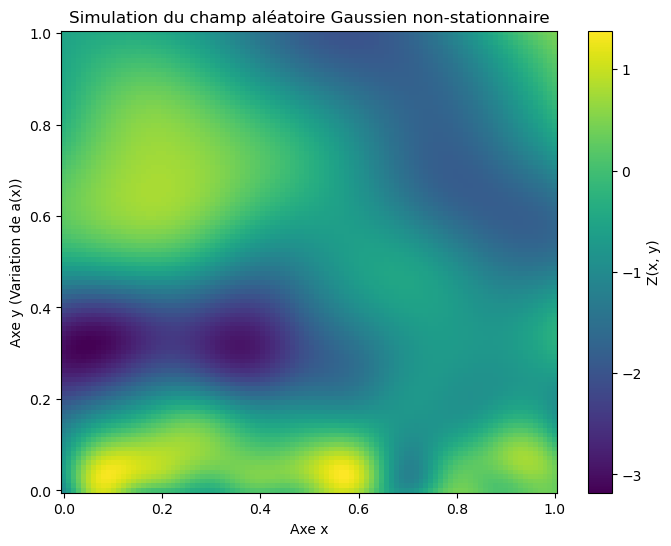

In [13]:
N = 100
M = 500       
a_min = 0.01  
a_max = 0.1
a_inf = a_min 

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

A = a_min + (a_max - a_min) * Y

Z = np.zeros((N, N))


cov_W = (2 / a_inf) * np.eye(2)
sigma_W = np.sqrt(2 / a_inf)
W = sigma_W * np.random.randn(M, 2)

phi = np.random.uniform(0, 2 * np.pi, M)

for m in range(M):
    Wm = W[m]
    norm_Wm_sq = Wm[0]**2 + Wm[1]**2

    ratio = (A / a_inf) * np.exp(- (A - a_inf) * norm_Wm_sq / 4)
    
    dot_product = Wm[0] * X + Wm[1] * Y
    
    Z += np.sqrt(2 * ratio) * np.cos(dot_product + phi[m])

Z = Z / np.sqrt(M)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
plt.colorbar(label='Z(x, y)')
plt.title("Simulation du champ aléatoire Gaussien non-stationnaire")
plt.xlabel("Axe x")
plt.ylabel("Axe y (Variation de a(x))")
plt.show()

Visuellement, on observe que la "texture" ou la "rugosité" du champ aléatoire évolue le long de l'axe des ordonnées (axe $y$).

* **Dans la partie basse du domaine ($y$ proche de 0) :** La valeur de $a(x)$ est proche de $a_{min} = 0.01$. Dans la formule de covariance, un petit paramètre $a$ implique une décroissance très rapide de la corrélation en fonction de la distance. Par conséquent, le champ présente des variations spatiales très rapides, avec des structures petites et fines (aspect haute fréquence).

* **Dans la partie haute du domaine ($y$ proche de 1) :** La valeur de $a(x)$ s'approche de $a_{max} = 0.1$. La décroissance de la corrélation spatiale est plus lente. Le champ est donc beaucoup plus lisse, avec des "taches" ou des structures beaucoup plus larges et étalées (aspect basse fréquence).

Cette évolution visuelle valide le caractère non-stationnaire de notre simulation : les propriétés locales du champ aléatoire (ici, son échelle de fluctuation spatiale) dépendent directement de sa position dans le domaine.